# Italy Test Set Evaluation

Runs the trained model on the geographic holdout 

## 1. Imports and setup

In [ ]:
import os
os.makedirs('figures/italy', exist_ok=True)
import numpy as np
import torch
import torch.nn as nn
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
import sys as _sys; _sys.path.insert(0, __import__('os').path.abspath('.'))
from src.fill import fill_input_stack
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import pearsonr, binned_statistic
import numpy as np, matplotlib.pyplot as plt, torch, rasterio
from sklearn.metrics import r2_score
from scipy.stats import spearmanr, pearsonr

In [ ]:
BEST_MODEL_PATH = 'best_sweep_final_model.pt'

ck = torch.load(BEST_MODEL_PATH, map_location='cpu')
cfg = ck.get('config', {})
print('Model file:   ', BEST_MODEL_PATH)
print('Config:       ', cfg)
print('val_rmse:     ', ck.get('val_rmse'))
print('val_city_rmse:', ck.get('val_city_rmse'))


## 2. Model definition

In [3]:
class CNNSweep(nn.Module):
    def __init__(self, config):
        super().__init__()
        d        = config.get('dropout', 0.17454852770248158)
        n_layers = config.get('n_layers', 2)
        base_ch      = config.get('base_channels', 32)

        layers = []
        in_ch  = 9
        out_ch = base_ch
        for i in range(n_layers):
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
                nn.Dropout(d),
            ]
            if i < n_layers - 1:
                layers.append(nn.MaxPool2d(2, 2))
            in_ch  = out_ch
            out_ch = min(out_ch * 2, 256)

        self.conv_layers = nn.Sequential(*layers)
        self.final_ch    = in_ch

        self.fc_layers = nn.Sequential(
            nn.Linear(self.final_ch, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(d),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, x.shape[2] // 2, x.shape[3] // 2]
        x = self.fc_layers(x)
        return torch.sigmoid(x)


## 3. Paths and model loading

In [4]:
MODEL_PATH = BEST_MODEL_PATH
GDP_PATH   = r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif'
POP_PATH   = r'READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif'
LC_PATH    = r'READY_data\landuse_onehot\chen2015_lc_onehot.tif'
CISI_PATH  = r'READY_data\labels\2024_CISI_010deg_nearest.tif'
SHP_PATH   = r'ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp'

checkpoint = torch.load(MODEL_PATH, map_location=device)
config     = checkpoint.get('config', {})
PATCH_SIZE = config.get('patch_size', 16)
HALF       = PATCH_SIZE // 2

model = CNNSweep(config).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Model loaded from {MODEL_PATH}')
print(f'Config: {config}')

Model loaded from best_sweep_final_model.pt
Config: {'patch_size': 8, 'n_layers': 2, 'base_channels': 32, 'dropout': 0.17454852770248158, 'lr': 0.00011146905836052476, 'weight_decay': 9.910996083741572e-05, 'batch_size': 64, 'loss_fn': 'weighted_mse', 'scale': 100, 'oversample_factor': 20}


## 4. Load data and extract Italy pixels

In [5]:
with rasterio.open(GDP_PATH) as src:
    gdp = src.read(1).astype(np.float32)
with rasterio.open(POP_PATH) as src:
    pop = src.read(1).astype(np.float32)
with rasterio.open(LC_PATH) as src:
    lc = src.read().astype(np.float32)
with rasterio.open(CISI_PATH) as src:
    cisi      = src.read(1).astype(np.float32)
    transform = src.transform

input_stack = fill_input_stack(np.concatenate([gdp[np.newaxis], pop[np.newaxis], lc], axis=0))  # (9, H, W)

valid_mask = ~np.isnan(gdp) & ~np.isnan(pop) & ~np.isnan(cisi)
valid_idx  = np.argwhere(valid_mask)

# Geolocate pixels and identify Italy
rows, cols = valid_idx[:, 0], valid_idx[:, 1]
xs, ys = rasterio.transform.xy(transform, rows, cols)
points = gpd.GeoDataFrame(
    {"idx": np.arange(len(rows))},
    geometry=gpd.points_from_xy(xs, ys),
    crs="EPSG:4326"
)
world = gpd.read_file(SHP_PATH)[["NAME", "geometry"]]
joined = gpd.sjoin(points, world, how="left", predicate="within")
country_names = joined["NAME"].fillna("").values

italy_idx = valid_idx[country_names == "Italy"]
print(f"Total valid pixels: {len(valid_idx):,}")
print(f"Italy test pixels:  {len(italy_idx):,}")


Total valid pixels: 82,461
Italy test pixels:  3,316


## 5. Run inference on Italy pixels

In [6]:
patches, coords, preds_list = [], [], []

for i, j in italy_idx:
    pad_top    = max(0, HALF - i)
    pad_bottom = max(0, (i + HALF) - input_stack.shape[1])
    pad_left   = max(0, HALF - j)
    pad_right  = max(0, (j + HALF) - input_stack.shape[2])
    i0 = max(0, i - HALF); i1 = min(input_stack.shape[1], i + HALF)
    j0 = max(0, j - HALF); j1 = min(input_stack.shape[2], j + HALF)
    patch = input_stack[:, i0:i1, j0:j1].copy()
    if pad_top or pad_bottom or pad_left or pad_right:
        patch = np.pad(patch, ((0,0),(pad_top,pad_bottom),(pad_left,pad_right)), mode="edge")
    patches.append(patch)
    coords.append((i, j))

    if len(patches) == 512:
        batch = torch.FloatTensor(np.stack(patches)).to(device)
        with torch.no_grad():
            preds_list.extend(model(batch).cpu().numpy().flatten())
        patches, coords = [], []

if patches:
    batch = torch.FloatTensor(np.stack(patches)).to(device)
    with torch.no_grad():
        preds_list.extend(model(batch).cpu().numpy().flatten())

preds   = np.array(preds_list)
targets = np.array([cisi[i, j] for i, j in italy_idx])
print(f"Inference done. {len(preds):,} predictions.")


Inference done. 3,316 predictions.


## 6. Metrics

In [7]:
valid   = ~np.isnan(preds) & ~np.isnan(targets)
preds   = preds[valid]
targets = targets[valid]
print(f'Valid predictions: {valid.sum():,} / {len(valid):,}')

city_mask  = targets > 0.15
city_mask2 = targets > 0.20
rural_mask = ~city_mask

rmse_global    = float(np.sqrt(np.mean((targets - preds) ** 2)))
rmse_city      = float(np.sqrt(np.mean((targets[city_mask] - preds[city_mask]) ** 2))) if city_mask.sum() > 0 else float('nan')
r2_global      = float(r2_score(targets, preds))
r2_city        = float(r2_score(targets[city_mask], preds[city_mask])) if city_mask.sum() > 0 else float('nan')
pred_max       = float(preds.max())
underpr_15     = float(np.mean(targets[city_mask]  - preds[city_mask]))  if city_mask.sum()  > 0 else float('nan')
underpr_20     = float(np.mean(targets[city_mask2] - preds[city_mask2])) if city_mask2.sum() > 0 else float('nan')

print(f'{"Metric":<30} {"Global":>10} {"City (>0.15)":>14}')
print('-' * 56)
print(f'{"RMSE":<30} {rmse_global:>10.4f} {rmse_city:>14.4f}')
print(f'{"R2":<30} {r2_global:>10.4f} {r2_city:>14.4f}')
print(f'{"pred_max":<30} {pred_max:>10.4f}')
print(f'{"Mean underprediction t=0.15":<30} {underpr_15:>10.4f}')
print(f'{"Mean underprediction t=0.20":<30} {underpr_20:>10.4f}')
print(f'{"N city pixels (>0.15)":<30} {city_mask.sum():>10,}')
print(f'{"N total pixels":<30} {len(targets):>10,}')


Valid predictions: 3,316 / 3,316
Metric                             Global   City (>0.15)
--------------------------------------------------------
RMSE                               0.0626         0.0656
R2                                -0.6655        -0.0166
pred_max                           0.4217
Mean underprediction t=0.15        0.0197
Mean underprediction t=0.20        0.0364
N city pixels (>0.15)                 157
N total pixels                      3,316


In [ ]:
# ── D. Additional Italy test metrics ─────────────────────────────────────────

_mae_g   = float(np.mean(np.abs(preds - targets)))
_max_act = float(targets.max())
_max_pred= float(preds.max())
_mean_act= float(targets.mean())
_mean_pred=float(preds.mean())

_sp_all,  _ = spearmanr(preds,            targets)
_sp_city, _ = spearmanr(preds[city_mask], targets[city_mask]) if city_mask.sum() > 1 else (float('nan'), None)

_baseline_city_rmse = float(np.sqrt(np.mean((targets[city_mask] - targets[city_mask].mean())**2)))

_frac_act  = float(city_mask.sum()) / len(targets)
_frac_pred = float((preds > 0.15).sum()) / len(preds)

# Bias decomposition
_mse_g       = float(np.mean((preds - targets)**2))
_mse_c       = float(np.mean((preds[city_mask] - targets[city_mask])**2)) if city_mask.sum() else float('nan')
_bias_g      = float(np.mean(preds - targets))
_bias_c      = float(np.mean(preds[city_mask] - targets[city_mask])) if city_mask.sum() else float('nan')
_bias2_g_pct = (_bias_g**2) / _mse_g * 100 if _mse_g else float('nan')
_bias2_c_pct = (_bias_c**2) / _mse_c * 100 if _mse_c else float('nan')

print(f"{'Metric':<40} {'Global':>10} {'City (>0.15)':>14}")
print('-' * 66)
print(f"{'MAE':<40} {_mae_g:>10.4f} {'—':>14}")
print(f"{'Max actual CISI':<40} {_max_act:>10.4f} {'—':>14}")
print(f"{'Max predicted CISI':<40} {_max_pred:>10.4f} {'—':>14}")
print(f"{'Mean actual':<40} {_mean_act:>10.4f} {'—':>14}")
print(f"{'Mean predicted':<40} {_mean_pred:>10.4f} {'—':>14}")
print(f"{'Spearman r':<40} {_sp_all:>10.4f} {_sp_city:>14.4f}")
print(f"{'Constant-baseline city RMSE':<40} {'—':>10} {_baseline_city_rmse:>14.4f}")
print(f"{'Fraction actual > 0.15':<40} {_frac_act:>10.4f} {'—':>14}")
print(f"{'Fraction predicted > 0.15':<40} {_frac_pred:>10.4f} {'—':>14}")
print()
print("Bias decomposition:")
print(f"  Global: mean signed error = {_bias_g:.5f}, bias^2 = {_bias_g**2:.6f}, "
      f"{_bias2_g_pct:.1f}% of total MSE ({_mse_g:.6f})")
print(f"  City:   mean signed error = {_bias_c:.5f}, bias^2 = {_bias_c**2:.6f}, "
      f"{_bias2_c_pct:.1f}% of total MSE ({_mse_c:.6f})")


In [ ]:
# preds, targets already loaded (Italy test set)
bands = [
    ("near-zero  (< 0.02)",      targets < 0.02),
    ("low        (0.02–0.15)",   (targets >= 0.02) & (targets < 0.15)),
    ("city       (>= 0.15)",     targets >= 0.15),
]

print(f"{'band':<24}{'n':>6}{'mean signed err':>18}{'mean obs':>11}{'mean pred':>11}")
for name, m in bands:
    err = preds[m] - targets[m]
    print(f"{name:<24}{m.sum():>6}{err.mean():>18.4f}"
          f"{targets[m].mean():>11.4f}{preds[m].mean():>11.4f}")

## 7. Scatter plot — predicted vs actual

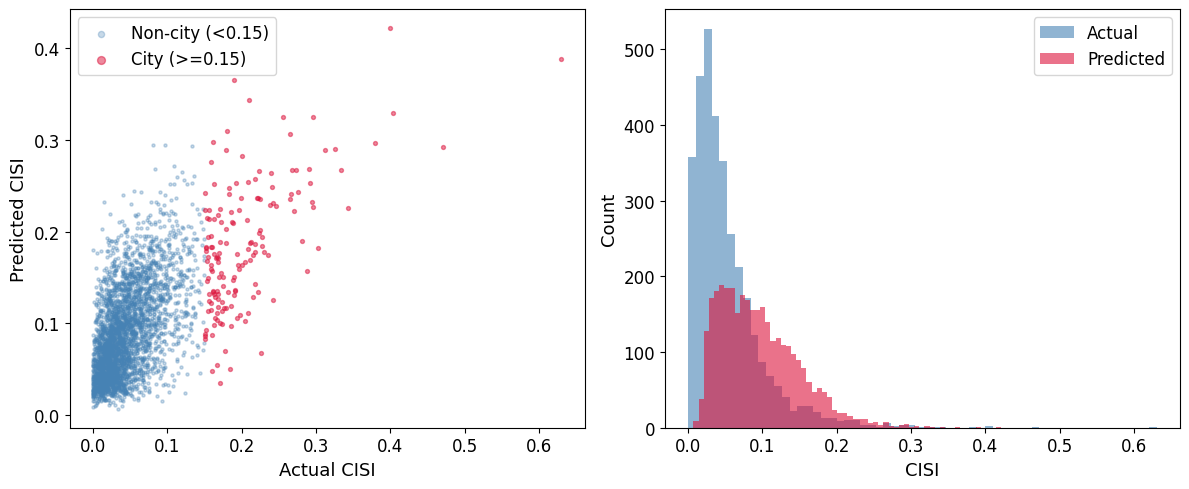

In [10]:
FS = 13
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(targets[rural_mask], preds[rural_mask], alpha=0.3, s=5, color='steelblue', label='Non-city (<0.15)')
axes[0].scatter(targets[city_mask],  preds[city_mask],  alpha=0.5, s=8, color='crimson',   label='City (>=0.15)')
axes[0].set_xlabel('Actual CISI', fontsize=FS)
axes[0].set_ylabel('Predicted CISI', fontsize=FS)
axes[0].tick_params(labelsize=FS - 1)
axes[0].legend(markerscale=2, fontsize=FS - 1)

axes[1].hist(targets, bins=60, alpha=0.6, label='Actual',    color='steelblue')
axes[1].hist(preds,   bins=60, alpha=0.6, label='Predicted', color='crimson')
axes[1].set_xlabel('CISI', fontsize=FS)
axes[1].set_ylabel('Count', fontsize=FS)
axes[1].tick_params(labelsize=FS - 1)
axes[1].legend(fontsize=FS - 1)

plt.tight_layout()
plt.savefig('figures/italy/scatter_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Spatial map — predictions and errors over Italy

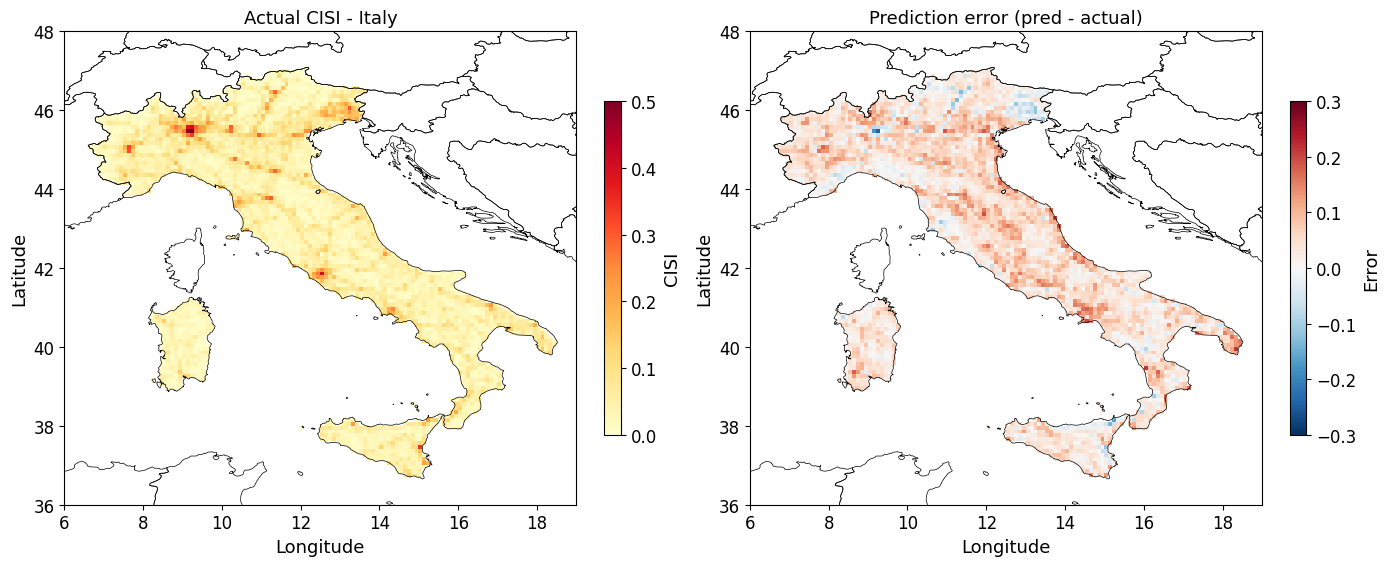

In [11]:
FS = 13
with rasterio.open(CISI_PATH) as src:
    H, W   = src.height, src.width
    bounds = src.bounds

pred_map   = np.full((H, W), np.nan)
error_map  = np.full((H, W), np.nan)
actual_map = np.full((H, W), np.nan)

for (i, j), p, t in zip(italy_idx, preds, targets):
    pred_map[i, j]   = p
    error_map[i, j]  = p - t
    actual_map[i, j] = t

world_shp = gpd.read_file(SHP_PATH)
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(actual_map, cmap='YlOrRd', vmin=0, vmax=0.5,
                     origin='upper', extent=ext, aspect='auto')
world_shp.boundary.plot(ax=axes[0], linewidth=0.5, color='black')
axes[0].set_xlim(6, 19); axes[0].set_ylim(36, 48)
axes[0].set_title('Actual CISI - Italy', fontsize=FS)
axes[0].set_xlabel('Longitude', fontsize=FS); axes[0].set_ylabel('Latitude', fontsize=FS)
axes[0].tick_params(labelsize=FS - 1)
cb0 = plt.colorbar(im0, ax=axes[0], label='CISI', fraction=0.03)
cb0.set_label('CISI', fontsize=FS); cb0.ax.tick_params(labelsize=FS - 1)

im1 = axes[1].imshow(error_map, cmap='RdBu_r', vmin=-0.3, vmax=0.3,
                     origin='upper', extent=ext, aspect='auto')
world_shp.boundary.plot(ax=axes[1], linewidth=0.5, color='black')
axes[1].set_xlim(6, 19); axes[1].set_ylim(36, 48)
axes[1].set_title('Prediction error (pred - actual)', fontsize=FS)
axes[1].set_xlabel('Longitude', fontsize=FS); axes[1].set_ylabel('Latitude', fontsize=FS)
axes[1].tick_params(labelsize=FS - 1)
cb1 = plt.colorbar(im1, ax=axes[1], label='Error', fraction=0.03)
cb1.set_label('Error', fontsize=FS); cb1.ax.tick_params(labelsize=FS - 1)

plt.tight_layout()
plt.savefig('figures/italy/spatial_error_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 8b. Italy map — actual vs predicted side by side

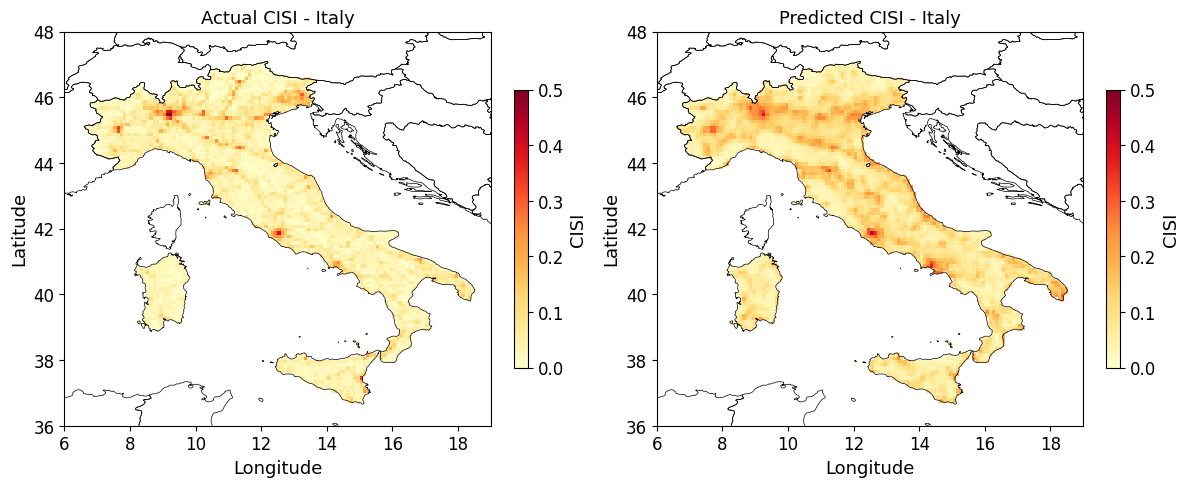

In [12]:
FS = 13
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

for ax, data, title in [
    (axes[0], actual_map, 'Actual CISI - Italy'),
    (axes[1], pred_map,   'Predicted CISI - Italy'),
]:
    im = ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=0.5,
                   origin='upper', extent=ext, aspect='auto')
    world_shp.boundary.plot(ax=ax, linewidth=0.5, color='black')
    ax.set_xlim(6, 19); ax.set_ylim(36, 48)
    ax.set_title(title, fontsize=FS)
    ax.set_xlabel('Longitude', fontsize=FS); ax.set_ylabel('Latitude', fontsize=FS)
    ax.tick_params(labelsize=FS - 1)
    cb = plt.colorbar(im, ax=ax, label='CISI', fraction=0.03)
    cb.set_label('CISI', fontsize=FS); cb.ax.tick_params(labelsize=FS - 1)

plt.tight_layout()
plt.savefig('figures/italy/spatial_pred_vs_actual_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. CISI density vs prediction error

Shows how absolute and signed error relate to actual CISI value. The binned mean signed error reveals systematic over/underprediction at different CISI levels.

In [ ]:
FS = 13

abs_error    = np.abs(preds - targets)
signed_error = preds - targets

bins        = np.linspace(0, targets.max(), 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

mean_abs_err,    _, _ = binned_statistic(targets, abs_error,    statistic='mean', bins=bins)
mean_signed_err, _, _ = binned_statistic(targets, signed_error, statistic='mean', bins=bins)

r, p = pearsonr(targets, signed_error)
print(f'Pearson r (CISI vs signed error): {r:.4f}  p={p:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(targets, abs_error, alpha=0.15, s=4, color='steelblue')
axes[0].set_xlabel('Actual CISI', fontsize=FS)
axes[0].set_ylabel('Absolute error |pred - actual|', fontsize=FS)
axes[0].set_title('CISI density vs absolute error', fontsize=FS)
axes[0].tick_params(labelsize=FS - 1)

bar_colors = ['crimson' if v > 0 else 'steelblue' for v in mean_signed_err]
axes[1].bar(bin_centers, mean_signed_err, width=(bins[1]-bins[0])*0.8, color=bar_colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Actual CISI', fontsize=FS)
axes[1].set_ylabel('Mean signed error (pred - actual)', fontsize=FS)
axes[1].set_title(f'Systematic bias by CISI level  r={r:.3f}', fontsize=FS)
axes[1].tick_params(labelsize=FS - 1)

plt.tight_layout()
plt.savefig('figures/italy/error_vs_cisi_bin.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Pixel distribution — actual vs predicted CISI (Italy)

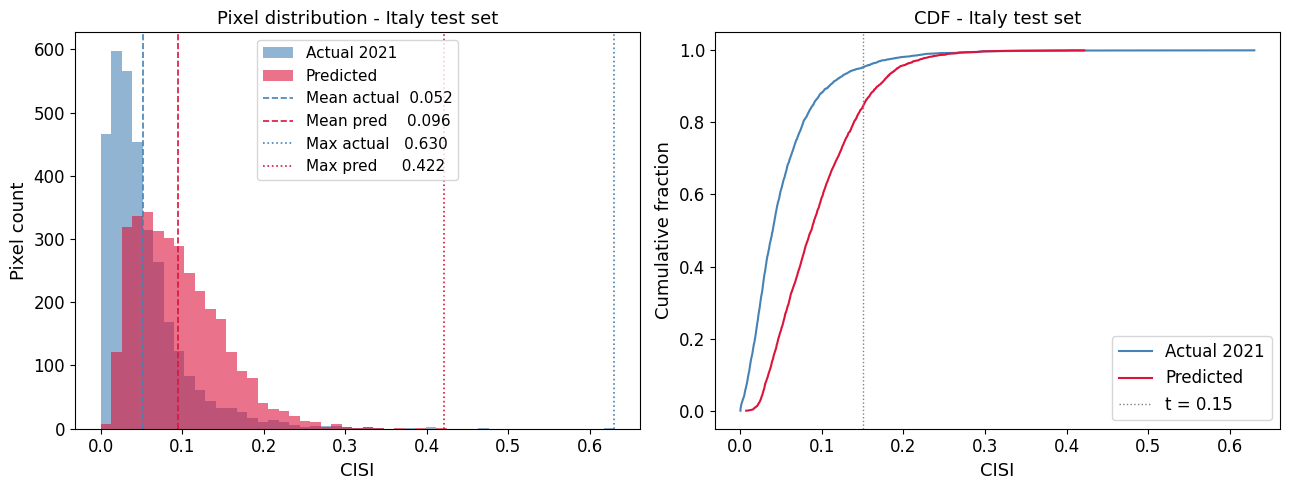

In [14]:
FS = 13
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins = np.linspace(0, max(targets.max(), preds.max()), 50)

axes[0].hist(targets, bins=bins, alpha=0.6, color='steelblue', label='Actual 2021')
axes[0].hist(preds,   bins=bins, alpha=0.6, color='crimson',   label='Predicted')
axes[0].axvline(targets.mean(), color='steelblue', linestyle='--', linewidth=1.2, label=f'Mean actual  {targets.mean():.3f}')
axes[0].axvline(preds.mean(),   color='crimson',   linestyle='--', linewidth=1.2, label=f'Mean pred    {preds.mean():.3f}')
axes[0].axvline(targets.max(),  color='steelblue', linestyle=':',  linewidth=1.2, label=f'Max actual   {targets.max():.3f}')
axes[0].axvline(preds.max(),    color='crimson',   linestyle=':',  linewidth=1.2, label=f'Max pred     {preds.max():.3f}')
axes[0].set_xlabel('CISI', fontsize=FS)
axes[0].set_ylabel('Pixel count', fontsize=FS)
axes[0].set_title('Pixel distribution - Italy test set', fontsize=FS)
axes[0].tick_params(labelsize=FS - 1)
axes[0].legend(fontsize=FS - 2)

axes[1].plot(np.sort(targets), np.linspace(0, 1, len(targets)), color='steelblue', label='Actual 2021')
axes[1].plot(np.sort(preds),   np.linspace(0, 1, len(preds)),   color='crimson',   label='Predicted')
axes[1].axvline(0.15, color='grey', linestyle=':', linewidth=1, label='t = 0.15')
axes[1].set_xlabel('CISI', fontsize=FS)
axes[1].set_ylabel('Cumulative fraction', fontsize=FS)
axes[1].set_title('CDF - Italy test set', fontsize=FS)
axes[1].tick_params(labelsize=FS - 1)
axes[1].legend(fontsize=FS - 1)

plt.tight_layout()
plt.savefig('figures/italy/cisi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# Calibration deciles and figure

In [ ]:
TAU = 0.15  # city threshold

def deciles(pred, obs):
    order = np.argsort(pred)
    pred, obs = pred[order], obs[order]
    idx = np.array_split(np.arange(len(pred)), 10)
    return [(pred[b].mean(), obs[b].mean(), len(b)) for b in idx]

# ── Validation split ──────────────────────────────────────────────────────────
with rasterio.open(r'READY_data\labels\eu_mask_010deg_ex_italy.tif') as s:
    _eu_ex = s.read(1).astype(bool)

_vm  = ~np.isnan(gdp) & ~np.isnan(pop) & ~np.isnan(cisi) & _eu_ex
_all = np.argwhere(_vm)
_cv  = np.array([cisi[i, j] for i, j in _all])
_hi  = np.where(_cv > TAU)[0];  _lo = np.where(_cv <= TAU)[0]
_rng = np.random.RandomState(42); _rng.shuffle(_hi); _rng.shuffle(_lo)
_vi  = np.concatenate([_hi[int(0.8*len(_hi)):], _lo[int(0.8*len(_lo)):]])
_val_idx = _all[_vi];  _val_obs_raw = _cv[_vi]

_vp = []
model.eval()
with torch.no_grad():
    for start in range(0, len(_val_idx), 512):
        _batch = []
        for ii, jj in _val_idx[start:start+512]:
            pt = max(0, HALF-ii);  pb = max(0, (ii+HALF)-input_stack.shape[1])
            pl = max(0, HALF-jj);  pr = max(0, (jj+HALF)-input_stack.shape[2])
            i0 = max(0, ii-HALF);  i1 = min(input_stack.shape[1], ii+HALF)
            j0 = max(0, jj-HALF);  j1 = min(input_stack.shape[2], jj+HALF)
            p = input_stack[:, i0:i1, j0:j1].copy()
            if pt or pb or pl or pr:
                p = np.pad(p, ((0,0),(pt,pb),(pl,pr)), mode='edge')
            _batch.append(p)
        _vp.extend(model(torch.FloatTensor(np.stack(_batch)).to(device)).cpu().numpy().flatten())

val_pred = np.array(_vp)
val_obs  = _val_obs_raw

italy_pred = preds
italy_obs  = targets

# ── Masks ─────────────────────────────────────────────────────────────────────
_vcm = val_obs   > TAU
_icm = italy_obs > TAU

# ── Counts ────────────────────────────────────────────────────────────────────
n_val        = len(val_pred)
n_val_city   = int(_vcm.sum())
n_italy      = len(italy_pred)
n_italy_city = int(_icm.sum())

# ── All metrics ───────────────────────────────────────────────────────────────
# Validation
val_global_rmse = float(np.sqrt(np.mean((val_pred - val_obs)**2)))
val_city_rmse   = float(np.sqrt(np.mean((val_pred[_vcm] - val_obs[_vcm])**2)))
val_global_r2   = float(r2_score(val_obs, val_pred))
val_city_r2     = float(r2_score(val_obs[_vcm], val_pred[_vcm])) if _vcm.sum() > 1 else float('nan')
val_spearman,        _ = spearmanr(val_pred, val_obs)
val_city_spearman,   _ = spearmanr(val_pred[_vcm], val_obs[_vcm]) if _vcm.sum() > 1 else (float('nan'), None)
val_pearson,         _ = pearsonr(val_pred, val_obs)
val_mean_obs    = float(val_obs.mean())
val_mean_pred   = float(val_pred.mean())
val_max_obs     = float(val_obs.max())
val_max_pred    = float(val_pred.max())
val_frac_obs    = float(_vcm.sum()) / n_val
val_frac_pred   = float((val_pred > TAU).sum()) / n_val

# Italy
italy_global_rmse = float(np.sqrt(np.mean((italy_pred - italy_obs)**2)))
italy_city_rmse   = float(np.sqrt(np.mean((italy_pred[_icm] - italy_obs[_icm])**2)))
italy_global_r2   = float(r2_score(italy_obs, italy_pred))
italy_city_r2     = float(r2_score(italy_obs[_icm], italy_pred[_icm])) if _icm.sum() > 1 else float('nan')
italy_spearman,      _ = spearmanr(italy_pred, italy_obs)
italy_city_spearman, _ = spearmanr(italy_pred[_icm], italy_obs[_icm]) if _icm.sum() > 1 else (float('nan'), None)
italy_pearson,       _ = pearsonr(italy_pred, italy_obs)
italy_mean_obs  = float(italy_obs.mean())
italy_mean_pred = float(italy_pred.mean())
italy_max_obs   = float(italy_obs.max())
italy_max_pred  = float(italy_pred.max())
italy_frac_obs  = float(_icm.sum()) / n_italy
italy_frac_pred = float((italy_pred > TAU).sum()) / n_italy

# ── Thesis table ──────────────────────────────────────────────────────────────
W = 28
print(f"{'Metric':<{W}} {'Val Global':>12} {'Val City':>10} {'Italy Global':>14} {'Italy City':>12}")
print('-' * (W + 52))
print(f"{'Pixels':<{W}} {n_val:>12,} {n_val_city:>10,} {n_italy:>14,} {n_italy_city:>12,}")
print(f"{'RMSE':<{W}} {val_global_rmse:>12.4f} {val_city_rmse:>10.4f} {italy_global_rmse:>14.4f} {italy_city_rmse:>12.4f}")
print(f"{'R2':<{W}} {val_global_r2:>12.4f} {val_city_r2:>10.4f} {italy_global_r2:>14.4f} {italy_city_r2:>12.4f}")
print(f"{'Spearman rho':<{W}} {val_spearman:>12.4f} {val_city_spearman:>10.4f} {italy_spearman:>14.4f} {italy_city_spearman:>12.4f}")
print(f"{'Pearson r':<{W}} {val_pearson:>12.4f} {'—':>10} {italy_pearson:>14.4f} {'—':>12}")
print(f"{'Mean observed':<{W}} {val_mean_obs:>12.4f} {'—':>10} {italy_mean_obs:>14.4f} {'—':>12}")
print(f"{'Mean predicted':<{W}} {val_mean_pred:>12.4f} {'—':>10} {italy_mean_pred:>14.4f} {'—':>12}")
print(f"{'Max observed':<{W}} {val_max_obs:>12.4f} {'—':>10} {italy_max_obs:>14.4f} {'—':>12}")
print(f"{'Max predicted':<{W}} {val_max_pred:>12.4f} {'—':>10} {italy_max_pred:>14.4f} {'—':>12}")
print(f"{'Frac > tau (observed)':<{W}} {val_frac_obs:>12.4f} {'—':>10} {italy_frac_obs:>14.4f} {'—':>12}")
print(f"{'Frac > tau (predicted)':<{W}} {val_frac_pred:>12.4f} {'—':>10} {italy_frac_pred:>14.4f} {'—':>12}")

# ── Decile tables ─────────────────────────────────────────────────────────────
vr = deciles(val_pred, val_obs)
ir = deciles(italy_pred, italy_obs)

for label, rows in [('VALIDATION SET', vr), ('ITALY TEST SET', ir)]:
    print(f'\n{label}')
    print(f'  {"Decile":>7}  {"mean_pred":>9}  {"mean_obs":>8}  {"n":>6}')
    print('  ' + '-'*38)
    for k, (mp, mo, cnt) in enumerate(rows):
        print(f'  {"D"+str(k+1):>7}  {mp:>9.4f}  {mo:>8.4f}  {cnt:>6}')

# ── Calibration curve ─────────────────────────────────────────────────────────
FS = 13
fig, ax = plt.subplots(figsize=(6, 5))
vx = [r[0] for r in vr];  vy = [r[1] for r in vr]
ix = [r[0] for r in ir];  iy = [r[1] for r in ir]
_lim = [0, max(max(vx), max(ix)) * 1.08]
ax.plot(_lim, _lim, 'k--', lw=1.0, label='Identity (perfect calibration)')
ax.plot(vx, vy, 'o-', color='#2166ac', lw=1.8, ms=6, label='Validation set (EU excl. Italy)')
ax.plot(ix, iy, 's-', color='#d73027', lw=1.8, ms=6, label='Italy test set')
ax.set_xlim(_lim);  ax.set_ylim(_lim)
ax.set_xlabel('Mean predicted CISI (decile bin)', fontsize=FS)
ax.set_ylabel('Mean observed CISI', fontsize=FS)
ax.legend(fontsize=FS-1, frameon=False)
ax.tick_params(labelsize=FS-1)
ax.grid(True, alpha=0.2)
fig.tight_layout()
fig.savefig('figures/calibration_curve.png', dpi=150, bbox_inches='tight')
print('\nSaved: figures/calibration_curve.png')
plt.show()


In [16]:
# ── Bias decomposition (for thesis placeholder) ───────────────────────────────
# MSE = bias^2 + noise^2
# Debiased R^2 = what R^2 would be if we shifted all predictions by -bias

def bias_decomp(pred, obs, label):
    bias   = float(np.mean(pred - obs))
    mse    = float(np.mean((pred - obs)**2))
    bias2  = bias**2
    pct    = bias2 / mse * 100
    var_obs = float(np.var(obs))          # population variance of observed
    debias_mse = mse - bias2
    debias_r2  = 1.0 - debias_mse / var_obs
    print(f"{label}")
    print(f"  Mean signed error (bias)       : {bias:+.5f}")
    print(f"  MSE                            : {mse:.6f}")
    print(f"  bias^2                         : {bias2:.6f}")
    print(f"  bias^2 as % of MSE             : {pct:.1f}%")
    print(f"  Debiased MSE (MSE - bias^2)    : {debias_mse:.6f}")
    print(f"  Debiased global R^2            : {debias_r2:+.4f}")
    return pct, debias_r2

print("=== Bias decomposition ===")
val_bias_pct,   val_debias_r2   = bias_decomp(val_pred,   val_obs,   "Validation (global)")
print()
italy_bias_pct, italy_debias_r2 = bias_decomp(italy_pred, italy_obs, "Italy (global)")
print()
print(f"THESIS PLACEHOLDER:")
print(f"  bias^2 is {val_bias_pct:.0f}% of MSE on validation and {italy_bias_pct:.0f}% on Italy")
print(f"  debiased global R^2: val = {val_debias_r2:+.3f}, Italy = {italy_debias_r2:+.3f}")


=== Bias decomposition ===
Validation (global)
  Mean signed error (bias)       : +0.03266
  MSE                            : 0.002325
  bias^2                         : 0.001067
  bias^2 as % of MSE             : 45.9%
  Debiased MSE (MSE - bias^2)    : 0.001258
  Debiased global R^2            : +0.2834

Italy (global)
  Mean signed error (bias)       : +0.04326
  MSE                            : 0.003923
  bias^2                         : 0.001872
  bias^2 as % of MSE             : 47.7%
  Debiased MSE (MSE - bias^2)    : 0.002051
  Debiased global R^2            : +0.1291

THESIS PLACEHOLDER:
  bias^2 is 46% of MSE on validation and 48% on Italy
  debiased global R^2: val = +0.283, Italy = +0.129


In [17]:
for name, m in [("near-zero <0.02", italy_obs<0.02),
                ("low 0.02-0.15", (italy_obs>=0.02)&(italy_obs<0.15)),
                ("city >=0.15", italy_obs>=0.15)]:
    print(f"{name:18s} n={m.sum():5d} obs={italy_obs[m].mean():.4f} "
          f"pred={italy_pred[m].mean():.4f} err={ (italy_pred[m]-italy_obs[m]).mean():+.4f}")

near-zero <0.02    n=  773 obs=0.0107 pred=0.0609 err=+0.0502
low 0.02-0.15      n= 2386 obs=0.0556 pred=0.1008 err=+0.0452
city >=0.15        n=  157 obs=0.2059 pred=0.1862 err=-0.0197
